### Adjacency Matrix

In [2]:
# A mapping from node names to indices for clarity
node_map_matrix = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
INF = float('inf')

# Adjacency matrix for the graph
adj_matrix = [
    # A,    B,    C,    D,    E,    F
    [0,    2,    4,    INF,  INF,  INF],  # Node A
    [INF,  0,    1,    7,    INF,  INF],  # Node B
    [INF,  INF,  0,    INF,  3,    INF],  # Node C
    [INF,  INF,  INF,  0,    INF,  1],    # Node D
    [INF,  INF,  INF,  2,    0,    5],    # Node E
    [INF,  INF,  INF,  INF,  INF,  0]     # Node F
]

In [ ]:
def dijkstra_mat(graph, start_value):
    V = len(graph)
    # 1. Initialization (Assuming start_value is the index of the start node)
    dist = [INF for i in range(V)]
    pi = [None for i in range(V)]
    finished = set()
    
    dist[start_value] = 0 # Distance from source to itself is 0

    while (len(finished) < V):
        min_dist = INF
        u = -1 
        
        for i in range(V):
            if i not in finished and dist[i] < min_dist:
                min_dist = dist[i]
                u = i

        if u == -1:
            break
            
        finished.add(u)

        for v in range(V):
            weight = graph[u][v]
            if weight > 0 and v not in finished:
                if dist[u] + weight < dist[v]:
                    dist[v] = dist[u] + weight
                    pi[v] = u 

    return dist, pi
# import heapq

# Assuming INF is defined as a very large number, e.g., float('inf')
# INF = float('inf') 

# def dijkstra_mat(graph, start_value):
#     V = len(graph)
    
#     # 1. Initialization (Assuming start_value is the index of the start node)
#     dist = [INF for i in range(V)]
#     pi = [None for i in range(V)]
    
#     # finished is not strictly necessary with a priority queue 
#     # if we handle stale entries, but let's keep it for clarity 
#     # to mark fully processed nodes, as it's common.
#     finished = set() 
    
#     # Priority Queue: stores tuples of (distance, vertex_index)
#     # The heap is ordered by distance (the first element of the tuple)
#     pq = [] 
    
#     dist[start_value] = 0 # Distance from source to itself is 0
    
#     # Add the start node to the priority queue
#     heapq.heappush(pq, (0, start_value)) 

#     # The loop continues as long as there are nodes to process in the priority queue
#     while pq:
#         # Extract the node 'u' with the minimum distance from the priority queue
#         min_dist_u, u = heapq.heappop(pq)
        
#         # Check for stale entries: If the distance in the PQ 
#         # is greater than the currently known shortest distance, skip it.
#         # This is a common pattern when using a PQ in Dijkstra's.
#         if min_dist_u > dist[u]:
#             continue
            
#         # Optimization: if we are using the 'finished' set to avoid processing 
#         # a node *after* it's been finalized (similar to your original code), 
#         # we can check this:
#         if u in finished:
#             continue
            
#         # Mark 'u' as finished (its shortest path is now finalized)
#         finished.add(u)

#         # Iterate through all neighbors 'v' of 'u'
#         for v in range(V):
#             weight = graph[u][v]
            
#             # Check for a valid edge (weight > 0 means an edge exists)
#             # We don't need to check 'v not in finished' here for relaxation, 
#             # as Dijkstra's allows relaxation to finished nodes; 
#             # however, if your graph matrix uses 0 for 'no edge' and positive for weight,
#             # this check 'weight > 0' handles the adjacency check.
#             if weight > 0:
#                 # Relaxation step
#                 if dist[u] + weight < dist[v]:
#                     dist[v] = dist[u] + weight
#                     pi[v] = u
                    
#                     # Add/Update the node 'v' in the priority queue
#                     # (This is the key step replacing your linear search)
#                     heapq.heappush(pq, (dist[v], v)) 

#     return dist, pi
start_node_index = 0 # Start at A
distances, predecessors = dijkstra_mat(adj_matrix, start_node_index)

In [4]:
print(distances) # Output: [0, 8, 9, 5, 7]
print(predecessors) # Output: [None, 3, 1, 0, 3] 

[0, 2, 3, 8, 6, 9]
[None, 0, 1, 4, 2, 3]


### Adjacency List

In [5]:
# A mapping from node names to indices for clarity
node_map_list = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}

# Mapping: 0:A, 1:B, 2:C, 3:D, 4:E, 5:F

# Adjacency list representation using a dictionary with integer keys
adj_dict_int = {
    0: [(1, 2), (2, 4)],
    1: [(2, 1), (3, 7)],
    2: [(4, 3)],
    3: [(5, 1)],
    4: [(3, 2), (5, 5)],
    5: []
}

In [6]:
import heapq
min_heap = [0,1,2,3,4,5]
heapq.heapify(min_heap)
min_heap

[0, 1, 2, 3, 4, 5]

In [7]:
# def dijkstra_list(adj_list, start):
#     V = len(adj_list.keys())
#     dist = [INF for i  in range(V)]
#     pi = [None for i  in range(V)]
#     visit = set()

#     dist[start] = 0
#     while len(visit) < len(adj_list):
#         min_dist = INF
#         u = -1
#         for i in range(V):
#             if i not in visit and dist[i] < min_dist:
#                 min_dist = dist[i]
#                 u = i
#         if u == -1:
#             break

#         visit.add(u)
#         for vert, weight in adj_list[u]:
#             if dist[u] + weight < dist[vert]:
#                 dist[vert] = dist[u] + weight
#                 pi[vert] = u
#     return dist, pi


INF = float('inf')

class Heap():

    def __init__(self):
        self.array = []
        self.size = 0
        self.pos = []

    def newMinHeapNode(self, v, dist):
        minHeapNode = [v, dist]
        return minHeapNode

    def swapMinHeapNode(self, a, b):
        t = self.array[a]
        self.array[a] = self.array[b]
        self.array[b] = t

    def minHeapify(self, idx):
        smallest = idx
        left = 2*idx + 1
        right = 2*idx + 2

        if (left < self.size and
           self.array[left][1]
            < self.array[smallest][1]):
            smallest = left

        if (right < self.size and
           self.array[right][1]
            < self.array[smallest][1]):
            smallest = right

        # The nodes to be swapped in min
        # heap if idx is not smallest
        if smallest != idx:

            # Swap positions
            self.pos[self.array[smallest][0]] = idx
            self.pos[self.array[idx][0]] = smallest

            # Swap nodes
            self.swapMinHeapNode(smallest, idx)

            self.minHeapify(smallest)

    # Standard function to extract minimum
    # node from heap
    def extractMin(self):

        # Return NULL wif heap is empty
        if self.isEmpty():
            return

        # Store the root node
        root = self.array[0]

        # Replace root node with last node
        lastNode = self.array[self.size - 1]
        self.array[0] = lastNode

        # Update position of last node
        self.pos[lastNode[0]] = 0
        self.pos[root[0]] = self.size - 1

        # Reduce heap size and heapify root
        self.size -= 1
        self.minHeapify(0)

        return root

    def isEmpty(self):
        return True if self.size == 0 else False

    def decreaseKey(self, v, dist):

        # Get the index of v in  heap array

        i = self.pos[v]

        # Get the node and update its dist value
        self.array[i][1] = dist

        # Travel up while the complete tree is
        # not heapified. This is a O(Logn) loop
        while (i > 0 and self.array[i][1] <
                  self.array[(i - 1) // 2][1]):

            # Swap this node with its parent
            self.pos[ self.array[i][0] ] = (i-1)//2
            self.pos[ self.array[(i-1)//2][0] ] = i
            self.swapMinHeapNode(i, (i - 1)//2 )

            # move to parent index
            i = (i - 1) // 2

    # A utility function to check if a given 
    # vertex 'v' is in min heap or not
    def isInMinHeap(self, v):

        if self.pos[v] < self.size:
            return True
        return False


def printArr(dist, n):
    print ("Vertex\tDistance from source")
    for i in range(n):
        print ("%d\t\t%d" % (i,dist[i]))

def dijkstra_list(adj_list, src):

        V = len(adj_list.keys())
        dist = []   # dist values used to pick minimum 
                    # weight edge in cut

        # minHeap represents set E
        minHeap = Heap()

        #  Initialize min heap with all vertices. 
        # dist value of all vertices
        for v in range(V):
            dist.append(INF)
            minHeap.array.append(minHeap.newMinHeapNode(v, dist[v]))
            minHeap.pos.append(v)

        minHeap.pos[src] = src
        dist[src] = 0
        minHeap.decreaseKey(src, dist[src])

        # Initially size of min heap is equal to V
        minHeap.size = V
        while not minHeap.isEmpty():
            newHeapNode = minHeap.extractMin()
            u = newHeapNode[0]
            for vert, weight in adj_list[u]:
                if (minHeap.isInMinHeap(vert) and weight + dist[u] < dist[vert]):
                        dist[vert] = weight + dist[u]
                        minHeap.decreaseKey(vert, dist[vert])

        # printArr(dist,V)

In [8]:
dijkstra_list(adj_dict_int, 0)

In [9]:
print(dijkstra_mat(adj_matrix, start_node_index))
print(dijkstra_list(adj_dict_int, 0))
print(dijkstra_list(adj_dict_int, 0))

([0, 2, 3, 8, 6, 9], [None, 0, 1, 4, 2, 3])
None
None


### Ideal ans

In [10]:
# The shortest distance from 'A' to every other node
ideal_distances = {
    'A': 0,
    'B': 2,
    'C': 3,   # via A -> B -> C
    'D': 8,   # via A -> B -> C -> E -> D
    'E': 6,   # via A -> B -> C -> E
    'F': 9    # via A -> B -> C -> E -> D -> F
}
# The predecessors to reconstruct the shortest paths
ideal_previous_nodes = {
    'B': 'A',
    'C': 'B',
    'E': 'C',
    'D': 'E',
    'F': 'D'
}

### Benchmarking corrected

In [11]:
import networkx as nx
import random

def generate_sparse_graph_nx(V, edge_prob=0.2, max_weight=10):
    """
    Generate a sparse weighted directed graph using NetworkX.
    - V: number of vertices
    - edge_prob: probability of each possible edge existing
    """
    G = nx.gnp_random_graph(V, edge_prob, directed=True)
    
    # Assign random weights to edges
    for (u, v) in G.edges():
        G[u][v]['weight'] = random.randint(1, max_weight)
    
    return G


def generate_dense_graph_nx(V, edge_prob=0.9, max_weight=10):
    """
    Generate a dense weighted directed graph using NetworkX.
    - edge_prob close to 1.0 means nearly all edges exist
    """
    G = nx.gnp_random_graph(V, edge_prob, directed=True)
    
    # Assign random weights
    for (u, v) in G.edges():
        G[u][v]['weight'] = random.randint(1, max_weight)
    
    return G


In [12]:
# Create a sparse and dense graph
sparse_G = generate_sparse_graph_nx(6)
dense_G = generate_dense_graph_nx(6)

print("Sparse Graph Edges with Weights:")
for (u, v, w) in sparse_G.edges(data='weight'):
    print(f"{u} -> {v}, weight = {w}")

print("\nDense Graph Edges with Weights:")
for (u, v, w) in dense_G.edges(data='weight'):
    print(f"{u} -> {v}, weight = {w}")


Sparse Graph Edges with Weights:
0 -> 1, weight = 2
0 -> 2, weight = 1
1 -> 5, weight = 3
2 -> 4, weight = 3
4 -> 0, weight = 4
4 -> 2, weight = 10
5 -> 2, weight = 2
5 -> 3, weight = 2

Dense Graph Edges with Weights:
0 -> 1, weight = 4
0 -> 2, weight = 8
0 -> 3, weight = 8
0 -> 4, weight = 4
0 -> 5, weight = 5
1 -> 0, weight = 6
1 -> 2, weight = 4
1 -> 3, weight = 10
1 -> 4, weight = 10
1 -> 5, weight = 2
2 -> 0, weight = 7
2 -> 1, weight = 2
2 -> 4, weight = 7
3 -> 0, weight = 9
3 -> 1, weight = 8
3 -> 2, weight = 4
3 -> 4, weight = 9
4 -> 2, weight = 3
4 -> 3, weight = 2
4 -> 5, weight = 1
5 -> 0, weight = 5
5 -> 1, weight = 3
5 -> 2, weight = 2
5 -> 3, weight = 10
5 -> 4, weight = 9


In [ ]:
def graph_to_formats(G, graph_name):
    adj_matrix = nx.adjacency_matrix(G, weight='weight').todense()
    adj_list_dict = {}
    for node in sorted(G.nodes()):
        # Get neighbors and their edge data
        neighbors_data = G.adj[node]
        # Format the output as: node -> [(neighbor, weight), ...]
        adj_list_entry = []
        for neighbor, data in neighbors_data.items():
            adj_list_entry.append((neighbor, data.get('weight', 1))) # Use weight, default to 1 if unweighted

        # print(f"Node {node}: {adj_list_entry}")
        adj_list_dict[node] = adj_list_entry

    # print("\n" + "="*50 + "\n")

    return adj_matrix, adj_list_dict

# Process both graphs
graph_to_formats(sparse_G, "Sparse Graph")
graph_to_formats(dense_G, "Dense Graph")

(array([[ 0,  4,  8,  8,  4,  5],
        [ 6,  0,  4, 10, 10,  2],
        [ 7,  2,  0,  0,  7,  0],
        [ 9,  8,  4,  0,  9,  0],
        [ 0,  0,  3,  2,  0,  1],
        [ 5,  3,  2, 10,  9,  0]]),
 {0: [(1, 4), (2, 8), (3, 8), (4, 4), (5, 5)],
  1: [(0, 6), (2, 4), (3, 10), (4, 10), (5, 2)],
  2: [(0, 7), (1, 2), (4, 7)],
  3: [(0, 9), (1, 8), (2, 4), (4, 9)],
  4: [(2, 3), (3, 2), (5, 1)],
  5: [(0, 5), (1, 3), (2, 2), (3, 10), (4, 9)]})

In [14]:
sparse_G = generate_sparse_graph_nx(6)
dense_G = generate_dense_graph_nx(6)

In [15]:
#Generate graph of fixed V
def generate_vary_graph_nx(V, E, max_weight=10):
    """
    Generate a sparse weighted directed graph using NetworkX.
    - V: number of vertices
    - edge_prob: probability of each possible edge existing
    """
    G = nx.gnm_random_graph(V, E, directed=True)
    
    # Assign random weights to edges
    for (u, v) in G.edges():
        G[u][v]['weight'] = random.randint(1, max_weight)
    
    return G

### Start

In [20]:
import time
V = 1000
edges_list = [
    1000,          # Sparse, near O(V)
    5000,          # Slightly denser
    50000,         # Moderate density
    200000,        # Higher moderate
    500000,        # High density
    900000,        # Very dense
    999000         # Almost complete, O(V^2) in number of edges
]

times_matrix = []
times_list = []

for E in edges_list:
    print(f"Processing {E}")
    graph = generate_vary_graph_nx(V, E, max_weight=20)
    adj_matrix, adj_list = graph_to_formats(sparse_G, "Graph")
    start_time_mat = time.time()
    dijkstra_mat(adj_matrix, 0)
    times_matrix.append(time.time() - start_time_mat)

    # List version
    start_time_list = time.time()
    dijkstra_list(adj_list, 0)
    times_list.append(time.time() - start_time_list)

Processing 1000
Processing 5000
Processing 50000
Processing 200000
Processing 500000
Processing 900000
Processing 999000


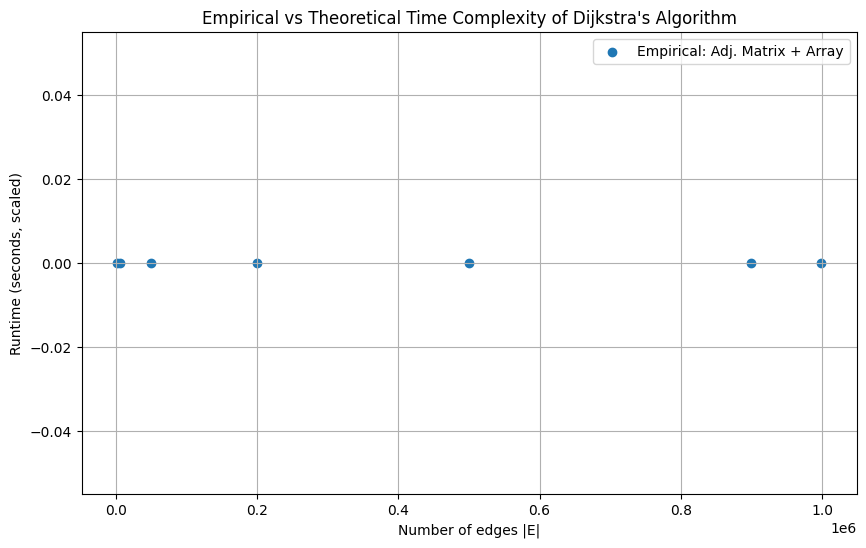

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.scatter(edges_list, times_matrix, marker='o', label="Empirical: Adj. Matrix + Array")
# plt.scatter(edges_list, times_list, marker='o', label="Empirical: Adj. List + Heap")
# plt.plot(sizes, theoretical_matrix, '--', color='red', label="Theoretical O(V²)")
# plt.plot(sizes, theoretical_list, '--', color='purple', label="Theoretical O(V² log V)")

plt.xlabel("Number of edges |E|")
plt.ylabel("Runtime (seconds, scaled)")
plt.title("Empirical vs Theoretical Time Complexity of Dijkstra's Algorithm")
plt.legend()
plt.grid(True)
plt.show()

# vary E

In [17]:
#Generate graph of fixed V
def generate_vary_graph_nx(V, E, max_weight=10):
    """
    Generate a sparse weighted directed graph using NetworkX.
    - V: number of vertices
    - edge_prob: probability of each possible edge existing
    """
    G = nx.gnm_random_graph(V, E, directed=True)
    
    # Assign random weights to edges
    for (u, v) in G.edges():
        G[u][v]['weight'] = random.randint(1, max_weight)
    
    return G


In [18]:
import time
V = 1000
edges_list = [1000, 3000, 5000, 10000, 20000, 40000, 80000]
times_matrix = []
times_list = []

for E in edges_list:
    print(f"Processing {E}")
    graph = generate_vary_graph_nx(V, E, max_weight=20)
    adj_matrix, adj_list = graph_to_formats(sparse_G, "Graph")
    start_time_mat = time.time()
    dijkstra_mat(adj_matrix, 0)
    times_matrix.append(time.time() - start_time_mat)

    # List version
    start_time_list = time.time()
    dijkstra_list(adj_list, 0)
    times_list.append(time.time() - start_time_list)

print("Matrix times:", times_matrix)
print("List times:", times_list)

# V = np.array(sizes, dtype=float)
# theoretical_matrix = []
# theoretical_list = []

# for i in range(len(sizes)):
#     theoretical_matrix.append(sizes[i] ** 2)  # O(V^2)
#     theoretical_list.append((sizes[i] + edges[i]) * np.log(sizes[i]))
# theoretical_matrix = theoretical_matrix / np.max(theoretical_matrix) * np.max(times_matrix)
# theoretical_list = theoretical_list / np.max(theoretical_list) * np.max(times_list)

Processing 1000
Processing 3000
Processing 5000
Processing 10000
Processing 20000
Processing 40000
Processing 80000
Matrix times: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
List times: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [19]:
plt.figure(figsize=(10,6))

plt.plot(edges_list, times_matrix, marker='o', label="Empirical: Adj. Matrix + Array")
plt.plot(edges_list, times_list, marker='o', label="Empirical: Adj. List + Heap")
# plt.plot(sizes, theoretical_matrix, '--', color='red', label="Theoretical O(V²)")
# plt.plot(sizes, theoretical_list, '--', color='purple', label="Theoretical O(V² log V)")

plt.xlabel("Number of edges |E|")
plt.ylabel("Runtime (seconds, scaled)")
plt.title("Empirical vs Theoretical Time Complexity of Dijkstra's Algorithm")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

### Sparse

In [ ]:
sizes = [10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
edges = []
times_matrix = []
times_list = []

for V in sizes:
    print(f"Processing {V}")
    sparse_G = generate_sparse_graph_nx(V)
    edges.append(sparse_G.number_of_edges())
    adj_matrix, adj_list = graph_to_formats(sparse_G, "Sparse Graph")
    
    # Matrix version
    start_time_mat = time.time()
    dijkstra_mat(adj_matrix, 0)
    times_matrix.append(time.time() - start_time_mat)

    # List version
    start_time_list = time.time()
    dijkstra_list(adj_list, 0)
    times_list.append(time.time() - start_time_list)

print("Matrix times:", times_matrix)
print("List times:", times_list)

V = np.array(sizes, dtype=float)
theoretical_matrix = []
theoretical_list = []

for i in range(len(sizes)):
    theoretical_matrix.append(sizes[i] ** 2)  # O(V^2)
    theoretical_list.append((sizes[i] + edges[i]) * np.log(sizes[i]))
theoretical_matrix = theoretical_matrix / np.max(theoretical_matrix) * np.max(times_matrix)
theoretical_list = theoretical_list / np.max(theoretical_list) * np.max(times_list)

Processing 10
Processing 100
Processing 200
Processing 300
Processing 400
Processing 500
Processing 600
Processing 700
Processing 800
Processing 900
Processing 1000
Matrix times: [0.0009009838104248047, 0.006050825119018555, 0.02270054817199707, 0.05345940589904785, 0.08335018157958984, 0.08872509002685547, 0.15857434272766113, 0.15755677223205566, 0.25110602378845215, 0.26021361351013184, 0.5831174850463867]
List times: [0.0, 0.0015399456024169922, 0.002176523208618164, 0.004431247711181641, 0.00715184211730957, 0.0033485889434814453, 0.014634847640991211, 0.020080089569091797, 0.014525890350341797, 0.02433013916015625, 0.0319364070892334]


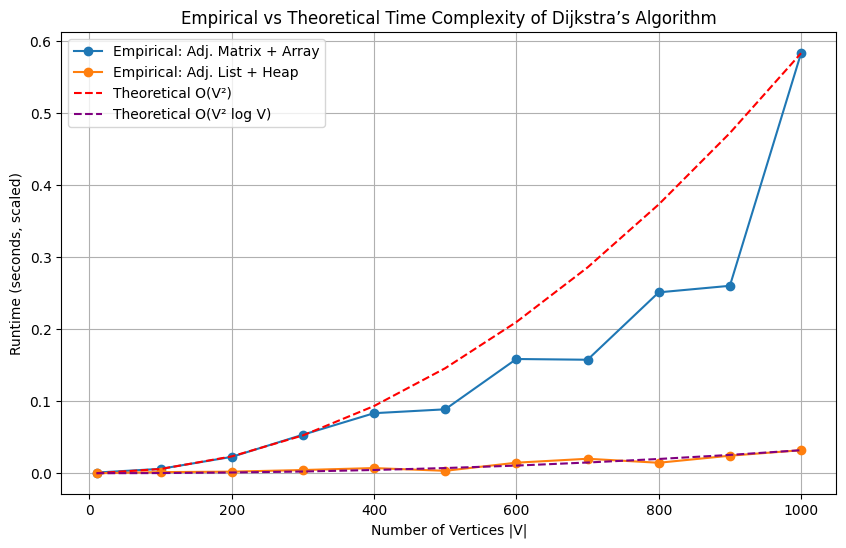

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(sizes, times_matrix, marker='o', label="Empirical: Adj. Matrix + Array")
plt.plot(sizes, times_list, marker='o', label="Empirical: Adj. List + Heap")
plt.plot(sizes, theoretical_matrix, '--', color='red', label="Theoretical O(V²)")
plt.plot(sizes, theoretical_list, '--', color='purple', label="Theoretical O(V² log V)")

plt.xlabel("Number of Vertices |V|")
plt.ylabel("Runtime (seconds, scaled)")
plt.title("Empirical vs Theoretical Time Complexity of Dijkstra’s Algorithm")
plt.legend()
plt.grid(True)
plt.show()

### Dense

In [ ]:
import time
sizes = [10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
times_matrix = []
times_list = []

for V in sizes:
    print(f"Processing {V}")
    dense_G = generate_dense_graph_nx(V)
    adj_matrix, adj_list = graph_to_formats(dense_G, "Dense Graph")
    
    # Matrix version
    start_time_mat = time.time()
    dijkstra_mat(adj_matrix, 0)
    times_matrix.append(time.time() - start_time_mat)

    # List version
    start_time_list = time.time()
    dijkstra_list(adj_list, 0)
    times_list.append(time.time() - start_time_list)

print("Matrix times:", times_matrix)
print("List times:", times_list)

theoretical_matrix = []
theoretical_list = []

for i in range(len(sizes)):
    theoretical_matrix.append(sizes[i] ** 2)  # O(V^2)
    theoretical_list.append((sizes[i] ** 2) * np.log(sizes[i]))
theoretical_matrix = theoretical_matrix / np.max(theoretical_matrix) * np.max(times_matrix)
theoretical_list = theoretical_list / np.max(theoretical_list) * np.max(times_list)

Processing 10
Processing 100
Processing 200
Processing 300
Processing 400
Processing 500
Processing 600
Processing 700
Processing 800
Processing 900
Processing 1000
Matrix times: [0.0, 0.0, 0.0249483585357666, 0.051564931869506836, 0.07096624374389648, 0.12030339241027832, 0.27532291412353516, 0.18123078346252441, 0.2494039535522461, 0.31586313247680664, 0.5521571636199951]
List times: [0.0, 0.0, 0.0, 0.020210981369018555, 0.031920671463012695, 0.026795625686645508, 0.05383586883544922, 0.05889105796813965, 0.06951665878295898, 0.07901334762573242, 0.14941811561584473]


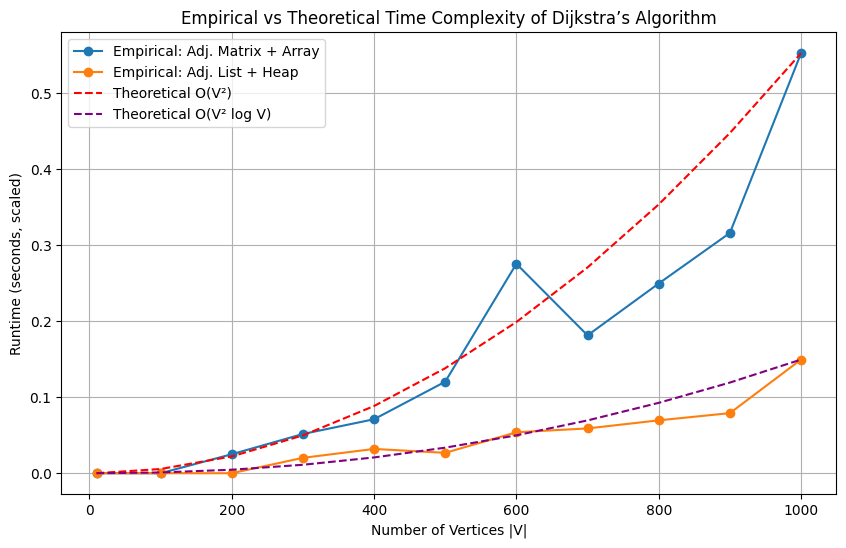

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(sizes, times_matrix, marker='o', label="Empirical: Adj. Matrix + Array")
plt.plot(sizes, times_list, marker='o', label="Empirical: Adj. List + Heap")
plt.plot(sizes, theoretical_matrix, '--', color='red', label="Theoretical O(V²)")
plt.plot(sizes, theoretical_list, '--', color='purple', label="Theoretical O(V² log V)")

plt.xlabel("Number of Vertices |V|")
plt.ylabel("Runtime (seconds, scaled)")
plt.title("Empirical vs Theoretical Time Complexity of Dijkstra’s Algorithm")
plt.legend()
plt.grid(True)
plt.show()

|E|=1000 done.
|E|=3000 done.
|E|=5000 done.
|E|=10000 done.
|E|=20000 done.
|E|=40000 done.
|E|=80000 done.


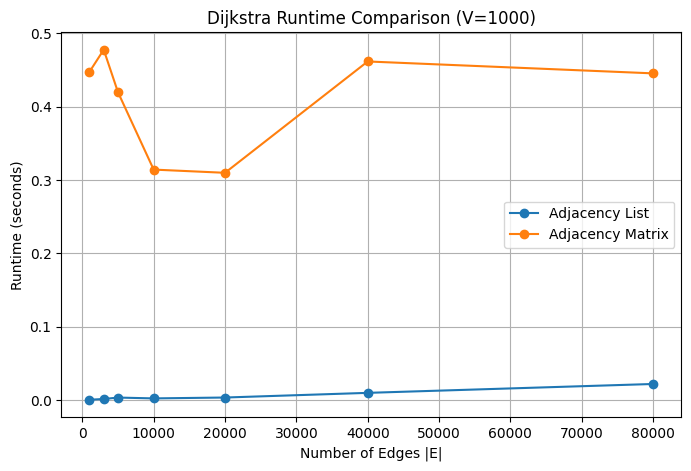

In [ ]:
import random
import time
import heapq
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Graph generation
# -----------------------------
def generate_random_graph(V, E, max_weight=10):
    edges = set()
    while len(edges) < E:
        u, v = random.randrange(V), random.randrange(V)
        if u != v:
            edges.add((u, v))

    # Build adjacency list
    adj_list = {i: [] for i in range(V)}
    for (u, v) in edges:
        weight = random.randint(1, max_weight)
        adj_list[u].append((v, weight))
    
    # Build adjacency matrix
    adj_matrix = np.full((V, V), float('inf'))
    np.fill_diagonal(adj_matrix, 0)
    for (u, v) in edges:
        adj_matrix[u][v] = random.randint(1, max_weight)
    
    return adj_list, adj_matrix


# -----------------------------
# Dijkstra (Adjacency List)
# -----------------------------
def dijkstra_list(adj_list, start):
    V = len(adj_list)
    dist = [float('inf')] * V
    dist[start] = 0
    pq = [(0, start)]
    
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, w in adj_list[u]:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                heapq.heappush(pq, (dist[v], v))
    return dist


# -----------------------------
# Dijkstra (Adjacency Matrix)
# -----------------------------
def dijkstra_matrix(adj_matrix, start):
    V = len(adj_matrix)
    visited = [False] * V
    dist = [float('inf')] * V
    dist[start] = 0
    
    for _ in range(V):
        # Pick min distance unvisited vertex
        u = min((d, i) for i, d in enumerate(dist) if not visited[i])[1]
        visited[u] = True
        for v in range(V):
            if not visited[v] and adj_matrix[u][v] != float('inf'):
                new_dist = dist[u] + adj_matrix[u][v]
                if new_dist < dist[v]:
                    dist[v] = new_dist
    return dist


# -----------------------------
# Runtime comparison
# -----------------------------
V = 1000
edges_list = [1000, 3000, 5000, 10000, 20000, 40000, 80000]
times_list = []
times_matrix = []

for E in edges_list:
    adj_list, adj_matrix = generate_random_graph(V, E)
    
    # --- List version ---
    start_time = time.perf_counter()
    dijkstra_list(adj_list, 0)
    times_list.append(time.perf_counter() - start_time)
    
    # --- Matrix version ---
    start_time = time.perf_counter()
    dijkstra_matrix(adj_matrix, 0)
    times_matrix.append(time.perf_counter() - start_time)
    
    print(f"|E|={E} done.")

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(edges_list, times_list, marker='o', label="Adjacency List")
plt.plot(edges_list, times_matrix, marker='o', label="Adjacency Matrix")
plt.xlabel("Number of Edges |E|")
plt.ylabel("Runtime (seconds)")
plt.title(f"Dijkstra Runtime Comparison (V={V})")
plt.legend()
plt.grid(True)
plt.show()
